In [1]:
import sympy as sp
import numpy as np
from tqdm import autonotebook as tqdm

import scipy.optimize as sp_opt
import scipy.integrate as sp_int
from matplotlib import pyplot as plt
import matplotlib.cm as cm

/var/folders/xb/gm1t4x5j3sbby4s80ty5k3z40000gn/T/ipykernel_91721/1982950012.py:3: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm import autonotebook as tqdm


In [107]:
x, y = sp.symbols("x, y")

fun = y - (y/x - sp.sin(y/x))
d_fun = sp.diff(fun, y)
s_fun = sp.integrate(fun, y)

call_fun = sp.lambdify([x, y], fun)
call_d_fun =  sp.lambdify([x, y], d_fun)
call_s_fun =  sp.lambdify([x, y], s_fun)

sp.solve(fun, y)

NotImplementedError: multiple generators [y, sin(y/x)]
No algorithms are implemented to solve equation y + sin(y/x) - y/x

/Users/rafael.calsaverini/miniforge3/envs/sandbox/lib/python3.10/site-packages/scipy/optimize/_minpack_py.py:175: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last five Jacobian evaluations.
  warnings.warn(msg, RuntimeWarning)


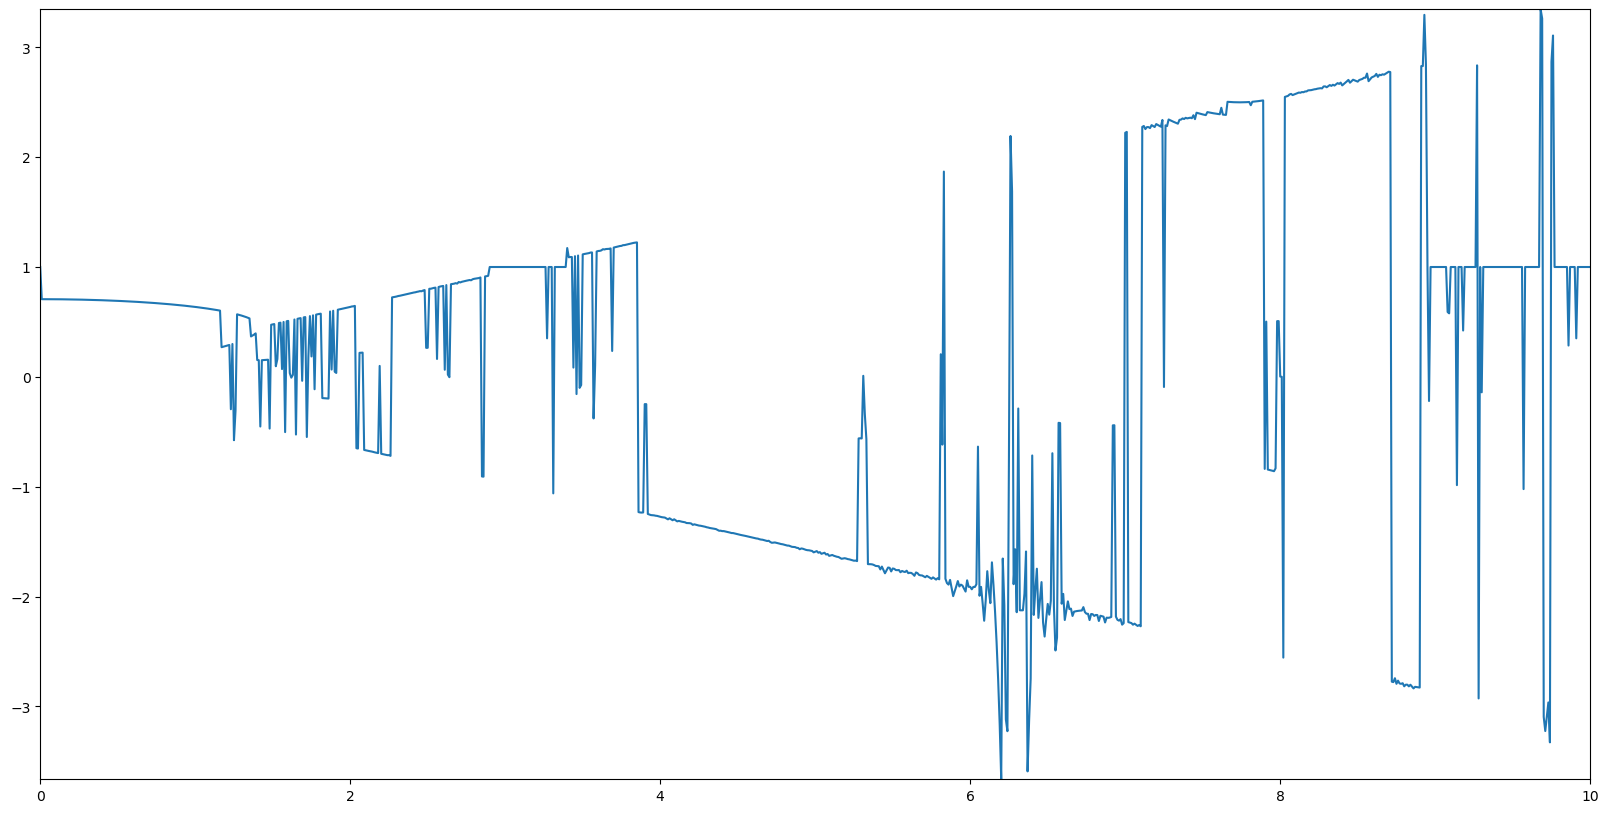

In [97]:
xs = np.linspace(0, 10, 1001)
ys = np.array([sp_opt.fsolve(call_fun, 1.0, args=(x,)) for x in xs])

fig, ax = plt.subplots(figsize=(20, 10))
ax.set_xlim(xs.min(), xs.max())
ax.set_ylim(ys.min(), ys.max())
ax.plot(xs, ys)

  0%|          | 0/201 [00:00<?, ?it/s]

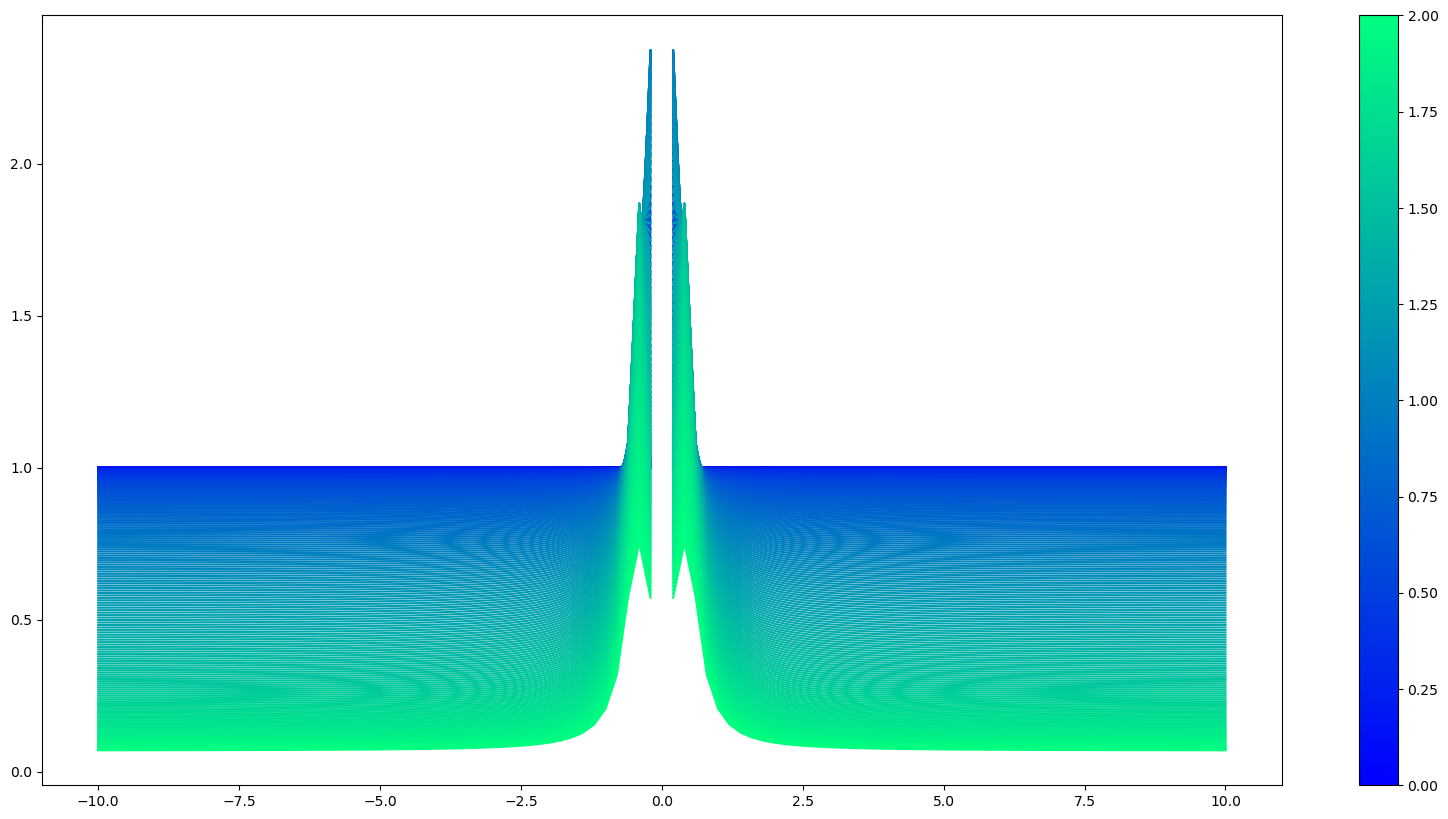

In [99]:
zs = np.linspace(-10, 10, 101)
xs = np.linspace(0, 2, 201)
cs = (xs - xs.min())/(xs.max() - xs.min())

fig, ax = plt.subplots(figsize=(20, 10))
# ax.set_xlim(zs.min(), zs.max())


color_map = cm.winter
max_p = 0.0

for (x, c) in tqdm.tqdm(list(zip(xs, cs))):
    ps = np.array([np.exp(-call_s_fun(z, x)) for z in zs])
#     norm_constant = sp_int.trapezoid(ps, zs)
    ax.plot(zs, ps, label=f"{x}", c=color_map(c))

sm = plt.cm.ScalarMappable(cmap=color_map, norm=plt.Normalize(vmin=xs.min(), vmax=xs.max()))
fig.colorbar(sm, ax=ax)

  0%|          | 0/11 [00:00<?, ?it/s]

  0%|          | 0/11 [00:00<?, ?it/s]

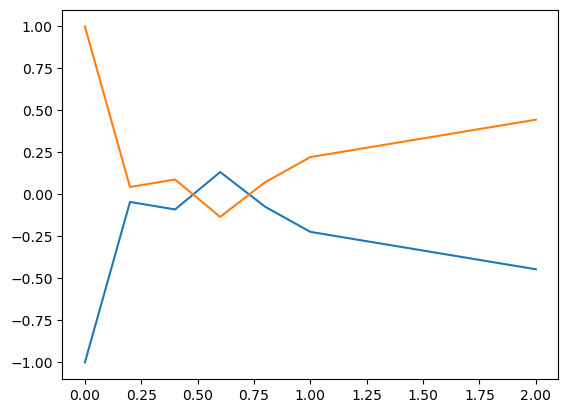

In [100]:
xs = np.linspace(0, 2, 11)

max_ls = [sp_opt.fmin(lambda z: call_s_fun(z, x), -1, disp=False) for x in tqdm.tqdm(xs)]
max_rs = [sp_opt.fmin(lambda z: call_s_fun(z, x), 1, disp=False) for x in tqdm.tqdm(xs)]

plt.plot(xs, max_ls)
plt.plot(xs, max_rs)